<a href="https://colab.research.google.com/github/aryan-singh326/Multi-Method-Options-Pricing-Engine-with-Greeks-Analysis-Calibration-API-Demo/blob/main/Multi_Method_Options_Pricing_Engine_with_Greeks_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-Method Options Pricing Engine with Greeks Analysis

**Executive Summary:** The project develops and compares three common ways to price financial options: an exact formula (Black-Scholes), a simulation based method (Monte Carlo), and a tree based numerical method (binomial trees). This project then tests all three against real market data. The primary outcome is a quantification of the accuracy-vs-speed tradeoff for the different methods. For a single option, the tree method is both faster and more accurate than simulation. The real advantage of simulation (handling multiple correlated assets or path-dependent payoffs) only becomes apparent in problems that trees cannot practically solve, which this project discusses but does not implement. When we calibrate the models to actual SPY option prices we find that the market prices options with a strike-dependent volatility, violating the constant volatility assumption all of these models make and exposing a great limitation of the model.

In [1]:
!pip install hypothesis
!pip install fastapi


# Interface Design

In [2]:
from abc import ABC, abstractmethod
import numpy as np
from scipy.stats import norm
import yfinance as yf
from hypothesis import given, strategies as st
import math
import pytest
from dataclasses import replace
from dataclasses import dataclass


In [3]:
@dataclass
class Option:
    spot: float
    strike: float
    expiry: float
    rate: float
    volatility: float
    option_type: str
    exercise_style: str

class PricingMethod(ABC):
  @abstractmethod
  def price(self, option: Option)->float:
      """Must be implemented by all subclasses."""
      pass
  @abstractmethod
  def greeks(self, option: Option)->dict:
      """Must be implemented by all subclasses."""
      pass
  @abstractmethod
  def metadata(self)->dict:
      """Must be implemented by all subclasses."""
      return {"method":"", "time_complexity":""}

# Black-Scholes

In [4]:
class BlackScholes(PricingMethod):
  def _d1_d2(self, option: Option):
    S, K, T, r, sigma = option.spot, option.strike, option.expiry, option.rate, option.volatility
    d1 = (np.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2
  def price(self, option: Option)->float:
    S, K, T, r, sigma = option.spot, option.strike, option.expiry, option.rate, option.volatility
    d1, d2 = self._d1_d2(option)
    if option.option_type == "call":
      return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
      return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
  def greeks(self, option: Option)->dict:
    S, K, T, r, sigma = option.spot, option.strike, option.expiry, option.rate, option.volatility
    d1, d2 = self._d1_d2(option)
    if option.option_type == "call":
      delta = norm.cdf(d1)
      gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
      theta = -S * norm.pdf(d1) * sigma / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)
      rho = T * K * np.exp(-r * T) * norm.cdf(d2)
      vega = S * norm.pdf(d1) * np.sqrt(T)
    else:
      delta = -norm.cdf(-d1)
      gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
      theta = -S * norm.pdf(d1) * sigma / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(-d2)
      rho = -T * K * np.exp(-r * T) * norm.cdf(-d2)
      vega = S * norm.pdf(d1) * np.sqrt(T)

    return {"delta": delta, "gamma":gamma, "theta":theta/252, "rho":rho/100, "vega":vega/100}

  def metadata(self)->dict:
    return {"method":"Black Scholes", "time_complexity":"O(1)"}


In [5]:
#TEST Black-Scholes

test_option = Option(
    spot=100.0,          # S: current underlying price
    strike=105.0,        # K: strike price
    expiry=0.5,           # T: time to expiration in years (6 months)
    rate=0.05,            # r: risk-free rate (5%)
    volatility=0.20,      # sigma: 20% annualized volatility
    option_type="call",
    exercise_style="european"
)

bs=BlackScholes()
print(bs.price(test_option))
print(bs.greeks(test_option))

4.581680167540007
{'delta': np.float64(0.46116022571905085), 'gamma': np.float64(0.028075683527420743), 'theta': np.float64(-0.030523229467073025), 'rho': np.float64(0.20767171202182538), 'vega': np.float64(0.2807568352742074)}


In [6]:
#Put-Call Parity

from hypothesis import given, strategies as st

@given(
    spot=st.floats(min_value=1, max_value=1000, allow_nan=False),
    strike=st.floats(min_value=1, max_value=1000, allow_nan=False),
    expiry=st.floats(min_value=0.01, max_value=5, allow_nan=False),
    rate=st.floats(min_value=0.0, max_value=0.15, allow_nan=False),
    volatility=st.floats(min_value=0.01, max_value=1.5, allow_nan=False),
)
def test_put_call_parity_property(spot, strike, expiry, rate, volatility):
    call_opt = Option(spot=spot, strike=strike, expiry=expiry, rate=rate,
                       volatility=volatility, option_type="call", exercise_style="european")
    put_opt = replace(call_opt, option_type="put")

    call_price = BlackScholes().price(call_opt)
    put_price = BlackScholes().price(put_opt)

    lhs = call_price - spot + strike * np.exp(-rate * expiry)
    assert np.isclose(lhs, put_price, atol=1e-6), f"Parity violated: {lhs} != {put_price} for S={spot},K={strike},T={expiry},r={rate},sigma={volatility}"

test_put_call_parity_property()
print("PASS: put-call parity holds across randomized inputs")



PASS: put-call parity holds across randomized inputs


# Monte-Carlo Simulation

In [7]:
class MonteCarlo(PricingMethod):
    def __init__(self, n_sims=100_000, seed=None):
        self.n_sims = n_sims
        self.rng = np.random.default_rng(seed)

    def _simulate_terminal_prices(self, option: Option, n_sims=None):
        n = n_sims or self.n_sims
        Z = self.rng.standard_normal(n)
        S, T, r, sigma = option.spot, option.expiry, option.rate, option.volatility
        S_T = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
        return S_T

    def _payoff(self, S_T, option: Option):
        if option.option_type == "call":
            return np.maximum(S_T - option.strike, 0)
        else:
            return np.maximum(option.strike - S_T, 0)

    def price(self, option: Option) -> float:
        S_T = self._simulate_terminal_prices(option)
        payoffs = self._payoff(S_T, option)
        discounted = np.exp(-option.rate * option.expiry) * payoffs
        return discounted.mean()

    def standard_error(self, option: Option) -> float:
        S_T = self._simulate_terminal_prices(option)
        payoffs = self._payoff(S_T, option)
        discounted = np.exp(-option.rate * option.expiry) * payoffs
        return discounted.std(ddof=1) / np.sqrt(self.n_sims)

    def greeks(self, option: Option) -> dict:
        raise NotImplementedError("Greeks via MC require bump-and-revalue or pathwise derivatives — add later if needed")

    def metadata(self) -> dict:
        return {"method": "monte_carlo", "complexity": "O(N)"}

    def _antithetic_terminal_prices(self, option: Option, n_pairs=None):
      n = (n_pairs or self.n_sims) // 2
      Z = self.rng.standard_normal(n)
      S, T, r, sigma = option.spot, option.expiry, option.rate, option.volatility
      drift = (r - 0.5 * sigma**2) * T
      diffusion = sigma * np.sqrt(T)
      S_T_plus = S * np.exp(drift + diffusion * Z)
      S_T_minus = S * np.exp(drift - diffusion * Z)
      return S_T_plus, S_T_minus

    def price_antithetic(self, option: Option) -> float:
        S_T_plus, S_T_minus = self._antithetic_terminal_prices(option)
        payoff_plus = self._payoff(S_T_plus, option)
        payoff_minus = self._payoff(S_T_minus, option)
        paired_avg = (payoff_plus + payoff_minus) / 2  # average WITHIN each pair first
        discounted = np.exp(-option.rate * option.expiry) * paired_avg
        return discounted.mean(), discounted.std(ddof=1) / np.sqrt(len(discounted))


    def price_control_variate(self, option: Option) -> float:
        S_T = self._simulate_terminal_prices(option)
        payoffs = self._payoff(S_T, option)
        disc_factor = np.exp(-option.rate * option.expiry)
        discounted_payoffs = disc_factor * payoffs

        # Control: also compute discounted payoff analytically isn't possible per-path,
        # so use the terminal price itself as control (E[S_T] is known analytically)
        control = disc_factor * S_T
        control_mean = option.spot  # E[S_T] under risk-neutral measure

        covariance = np.cov(discounted_payoffs, control)[0, 1]
        variance = np.var(control)
        beta = covariance / variance

        adjusted = discounted_payoffs - beta * (control - control_mean)
        return adjusted.mean(), adjusted.std(ddof=1) / np.sqrt(len(adjusted))


In [8]:
#Monte Carlo Test vs Black-Scholes

mc = MonteCarlo(n_sims=500_000, seed=42)
bs = BlackScholes()

mc_price = mc.price(test_option)
bs_price = bs.price(test_option)
se = mc.standard_error(test_option)

print(f"MC price: {mc_price:.4f} ± {1.96*se:.4f} (95% CI)")
print(f"BS price: {bs_price:.4f}")
assert abs(mc_price - bs_price) < 3 * se, "MC price outside expected range of BS price"

MC price: 4.5841 ± 0.0227 (95% CI)
BS price: 4.5817


In [9]:
#Monte Carlo Reproducibility Test

def test_seed_reproducibility():
    mc1 = MonteCarlo(n_sims=10_000, seed=123)
    mc2 = MonteCarlo(n_sims=10_000, seed=123)
    p1 = mc1.price(test_option)
    p2 = mc2.price(test_option)
    assert p1 == p2, f"Same seed gave different prices: {p1} vs {p2}"

test_seed_reproducibility()
print("PASS: seed reproducibility confirmed")

PASS: seed reproducibility confirmed


In [10]:
#Monte Carlo Variance Reduction Comparison
def test_variance_reduction():
    mc = MonteCarlo(n_sims=100_000, seed=7)
    naive_price = mc.price(test_option)
    naive_se = mc.standard_error(test_option)
    anti_price, anti_se = mc.price_antithetic(test_option)
    cv_price, cv_se = mc.price_control_variate(test_option)

    print(f"Naive:      {naive_price:.4f} ± {naive_se:.5f}")
    print(f"Antithetic: {anti_price:.4f} ± {anti_se:.5f}")
    print(f"Control:    {cv_price:.4f} ± {cv_se:.5f}")

    assert anti_se < naive_se, "Antithetic did not reduce variance"
    assert cv_se < naive_se, "Control variate did not reduce variance"

test_variance_reduction()

Naive:      4.5587 ± 0.02596
Antithetic: 4.5843 ± 0.02132
Control:    4.5713 ± 0.01359


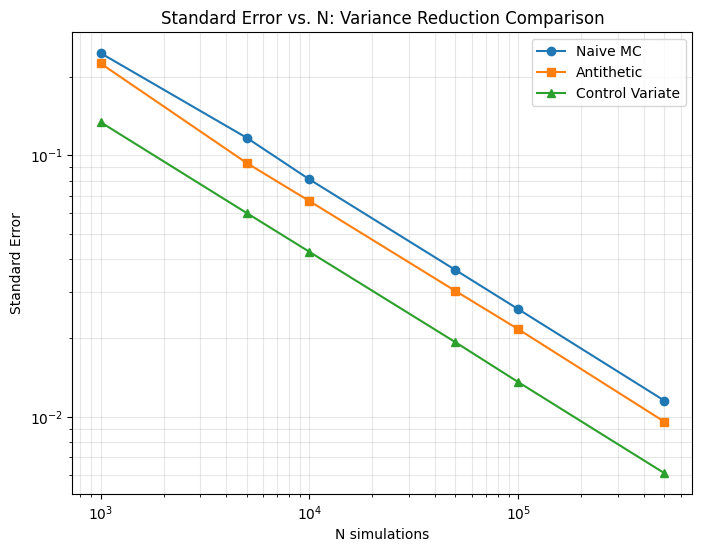

In [11]:
#Visualization
import matplotlib.pyplot as plt

Ns = [1000, 5000, 10000, 50000, 100000, 500000]
naive_ses, anti_ses, cv_ses = [], [], []

for n in Ns:
    mc = MonteCarlo(n_sims=n, seed=1)
    naive_ses.append(mc.standard_error(test_option))
    _, ase = mc.price_antithetic(test_option)
    anti_ses.append(ase)
    _, cse = mc.price_control_variate(test_option)
    cv_ses.append(cse)

plt.figure(figsize=(8,6))
plt.loglog(Ns, naive_ses, 'o-', label='Naive MC')
plt.loglog(Ns, anti_ses, 's-', label='Antithetic')
plt.loglog(Ns, cv_ses, '^-', label='Control Variate')
plt.xlabel('N simulations')
plt.ylabel('Standard Error')
plt.title('Standard Error vs. N: Variance Reduction Comparison')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.show()

# Binomial Tree

In [12]:
class BinomialTree(PricingMethod):
    def __init__(self, n_steps=500):
        self.n_steps = n_steps

    def _crr_params(self, option: Option, n_steps=None):
        n = n_steps or self.n_steps
        dt = option.expiry / n
        u = np.exp(option.volatility * np.sqrt(dt))
        d = 1 / u
        p = (np.exp(option.rate * dt) - d) / (u - d)
        return dt, u, d, p

    def price_european(self, option: Option, n_steps=None) -> float:
        n = n_steps or self.n_steps
        dt, u, d, p = self._crr_params(option, n)
        disc = np.exp(-option.rate * dt)


        j = np.arange(n + 1)
        S_T = option.spot * (u ** j) * (d ** (n - j))

        if option.option_type == "call":
            values = np.maximum(S_T - option.strike, 0)
        else:
            values = np.maximum(option.strike - S_T, 0)


        for step in range(n - 1, -1, -1):
            values = disc * (p * values[1:] + (1 - p) * values[:-1])

        return values[0]


    def price_american(self, option: Option, n_steps=None) -> float:
        n = n_steps or self.n_steps
        dt, u, d, p = self._crr_params(option, n)
        disc = np.exp(-option.rate * dt)

        j = np.arange(n + 1)
        S = option.spot * (u ** j) * (d ** (n - j))

        if option.option_type == "call":
            values = np.maximum(S - option.strike, 0)
        else:
            values = np.maximum(option.strike - S, 0)

        for step in range(n - 1, -1, -1):
            # asset prices at this step
            j = np.arange(step + 1)
            S_step = option.spot * (u ** j) * (d ** (step - j))

            continuation = disc * (p * values[1:] + (1 - p) * values[:-1])

            if option.option_type == "call":
                intrinsic = np.maximum(S_step - option.strike, 0)
            else:
                intrinsic = np.maximum(option.strike - S_step, 0)

            values = np.maximum(continuation, intrinsic)

        return values[0]


    def price_richardson(self, option: Option, n_steps: int) -> float:
        """Combine tree prices at n and 2n steps to accelerate convergence."""
        method = self.price_american if option.exercise_style == "american" else self.price_european
        P_n = method(option, n_steps=n_steps)
        P_2n = method(option, n_steps=2 * n_steps)
        return 2 * P_2n - P_n


    def price(self, option: Option) -> float:
        if option.exercise_style == "european":
            return self.price_european(option)
        else:
            return self.price_american(option)
    def greeks(self, option: Option) -> dict:
        raise NotImplementedError("Greeks via MC require bump-and-revalue or pathwise derivatives — add later if needed")

    def metadata(self) -> dict:
        return {"method": "binomial_tree", "complexity": "O(n^2)"}

n=   10: tree=4.70651, BS=4.58168, error=0.124833
n=   50: tree=4.58861, BS=4.58168, error=0.006934
n=  100: tree=4.58856, BS=4.58168, error=0.006882
n=  500: tree=4.58131, BS=4.58168, error=0.000366
n= 1000: tree=4.58290, BS=4.58168, error=0.001221
n= 5000: tree=4.58172, BS=4.58168, error=0.000043


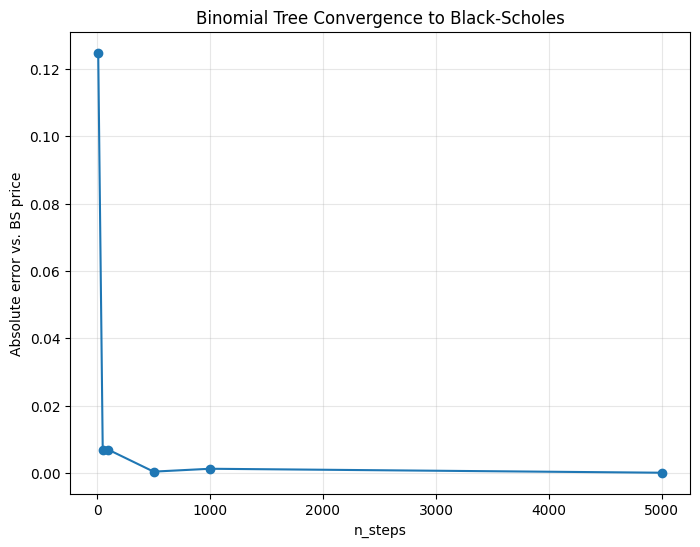

In [13]:
#Binomial Tree vs Black Scholes
bs_price = BlackScholes().price(test_option)
steps_to_test = [10, 50, 100, 500, 1000, 5000]
tree_prices = []

for n in steps_to_test:
    bt = BinomialTree()
    tree_prices.append(bt.price_european(test_option, n_steps=n))

for n, p in zip(steps_to_test, tree_prices):
    print(f"n={n:5d}: tree={p:.5f}, BS={bs_price:.5f}, error={abs(p-bs_price):.6f}")

plt.figure(figsize=(8,6))
plt.plot(steps_to_test, [abs(p - bs_price) for p in tree_prices], 'o-')
plt.xlabel('n_steps')
plt.ylabel('Absolute error vs. BS price')
plt.title('Binomial Tree Convergence to Black-Scholes')
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
#Test Richardson Extrapolation

base_steps = [50, 100, 250, 500]

for n in base_steps:
    bt = BinomialTree()
    raw = bt.price_european(test_option, n_steps=2*n)
    extrap = bt.price_richardson(test_option, n_steps=n)     # uses n + 2n internally
    print(f"n={n}: raw(2n)={raw:.6f} (err={abs(raw-bs_price):.6f}), "
          f"richardson={extrap:.6f} (err={abs(extrap-bs_price):.6f})")

n=50: raw(2n)=4.588562 (err=0.006882), richardson=4.588510 (err=0.006830)
n=100: raw(2n)=4.587691 (err=0.006010), richardson=4.586819 (err=0.005139)
n=250: raw(2n)=4.581314 (err=0.000366), richardson=4.578262 (err=0.003418)
n=500: raw(2n)=4.582901 (err=0.001221), richardson=4.584489 (err=0.002809)


In [15]:
#Test Binomial Tree

test_option_put = replace(test_option, option_type="put")

euro_put = BinomialTree().price_european(test_option_put)
amer_put = BinomialTree().price_american(test_option_put)

print(f"European put: {euro_put:.4f}")
print(f"American put: {amer_put:.4f}")
assert amer_put >= euro_put - 1e-8, "American price should never be less than European"

euro_call = BinomialTree().price_european(test_option)
amer_call = BinomialTree().price_american(test_option)
print(f"European call: {euro_call:.4f}")
print(f"American call: {amer_call:.4f}")
assert np.isclose(euro_call, amer_call, atol=1e-4), "American call should equal European call without dividends"

European put: 6.9889
American put: 7.4366
European call: 4.5813
American call: 4.5813


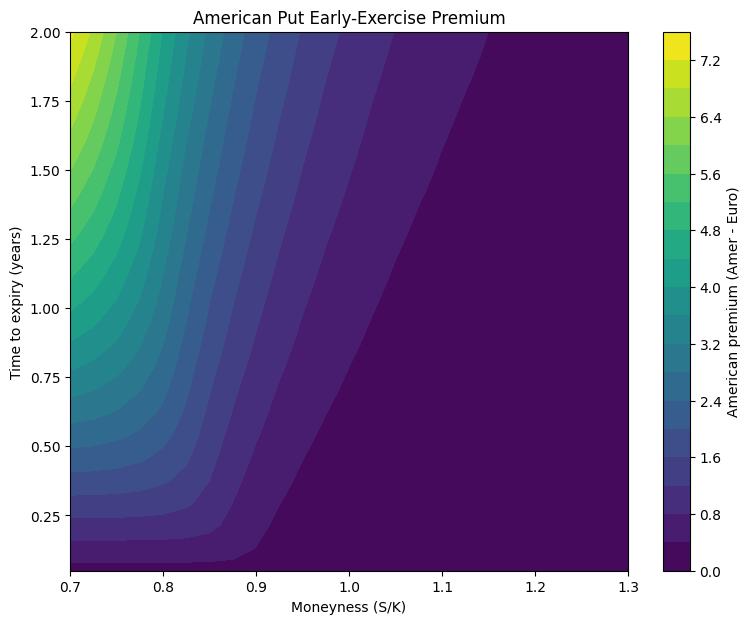

In [16]:
#American Premium

moneyness = np.linspace(0.7, 1.3, 25)  #S/K ratios
expiries = np.linspace(0.05, 2.0, 25)

premium_grid = np.zeros((len(expiries), len(moneyness)))

for i, T in enumerate(expiries):
    for j, m in enumerate(moneyness):
        opt = replace(test_option, spot=100 * m, strike=100.0, expiry=T, option_type="put")
        bt = BinomialTree(n_steps=200)
        euro = bt.price_european(opt)
        amer = bt.price_american(opt)
        premium_grid[i, j] = amer - euro

plt.figure(figsize=(9,7))
plt.contourf(moneyness, expiries, premium_grid, levels=20, cmap='viridis')
plt.colorbar(label='American premium (Amer - Euro)')
plt.xlabel('Moneyness (S/K)')
plt.ylabel('Time to expiry (years)')
plt.title('American Put Early-Exercise Premium')
plt.show()

# Comparative Analysis

In [17]:
#Reference Price and Error

def compute_error(method_price, reference_price):
    return abs(method_price - reference_price)

reference_price = BlackScholes().price(test_option)  #Ground truth for European case

In [18]:
#Benchmark Monte Carlo

import time

mc_results = []
Ns = [1000, 5000, 10000, 50000, 100000, 500000, 1000000]
seeds = [1, 2, 3, 4, 5]  # multiple seeds per N

for n in Ns:
    naive_errors, naive_times = [], []
    anti_errors, anti_times = [], []
    cv_errors, cv_times = [], []

    for seed in seeds:
        mc = MonteCarlo(n_sims=n, seed=seed)

        t0 = time.perf_counter()
        p_naive = mc.price(test_option)
        naive_times.append(time.perf_counter() - t0)
        naive_errors.append(compute_error(p_naive, reference_price))

        t0 = time.perf_counter()
        p_anti, _ = mc.price_antithetic(test_option)
        anti_times.append(time.perf_counter() - t0)
        anti_errors.append(compute_error(p_anti, reference_price))

        t0 = time.perf_counter()
        p_cv, _ = mc.price_control_variate(test_option)
        cv_times.append(time.perf_counter() - t0)
        cv_errors.append(compute_error(p_cv, reference_price))

    mc_results.append({"method": "MC-naive", "param": n,
                        "error_mean": np.mean(naive_errors), "error_std": np.std(naive_errors),
                        "runtime": np.mean(naive_times)})
    mc_results.append({"method": "MC-antithetic", "param": n,
                        "error_mean": np.mean(anti_errors), "error_std": np.std(anti_errors),
                        "runtime": np.mean(anti_times)})
    mc_results.append({"method": "MC-control", "param": n,
                        "error_mean": np.mean(cv_errors), "error_std": np.std(cv_errors),
                        "runtime": np.mean(cv_times)})

In [19]:
#Benchmark Binomial Tree

tree_results = []
tree_steps = [10, 50, 100, 250, 500, 1000, 2500, 5000]

for n in tree_steps:
    bt = BinomialTree()
    t0 = time.perf_counter()
    p = bt.price_european(test_option, n_steps=n)
    t = time.perf_counter() - t0
    tree_results.append({"method": "Binomial", "param": n, "error": compute_error(p, reference_price), "runtime": t})

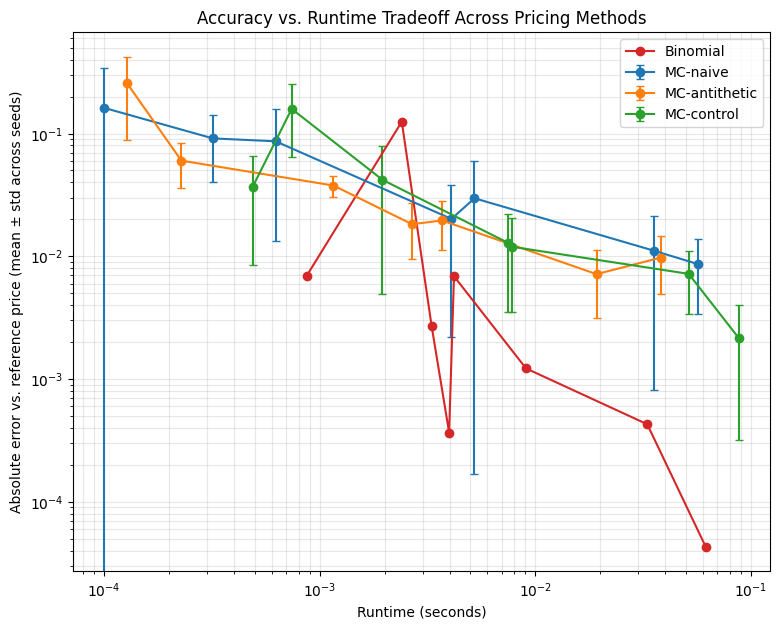

In [20]:
#Visualization of Combined Results

import pandas as pd

df = pd.DataFrame(mc_results + tree_results)  # tree_results doesn't need multi-seed, binomial tree is deterministic

plt.figure(figsize=(9,7))
for method in df["method"].unique():
    sub = df[df["method"] == method].sort_values("runtime")
    if "error_std" in sub.columns and sub["error_std"].notna().any():
        plt.errorbar(sub["runtime"], sub["error_mean"].clip(lower=1e-8),
                     yerr=sub["error_std"], fmt='o-', label=method, capsize=3)
    else:
        plt.plot(sub["runtime"], sub["error"].clip(lower=1e-8), 'o-', label=method)

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Runtime (seconds)")
plt.ylabel("Absolute error vs. reference price (mean ± std across seeds)")
plt.title("Accuracy vs. Runtime Tradeoff Across Pricing Methods")
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.show()

Naive Monte Carlo prices European options by simulating terminal values and averaging discounted payoffs. It never needs to know the option's value at intermediate times, only at expiry.

American exercise breaks this approach. At each point along a path, the holder must decide whether exercising now beats waiting, and that decision requires the conditional expected continuation value: given the current state, what is the option worth if held? A single simulated path cannot supply this. It is one draw from the future, not a distribution conditional on the current state.

The Longstaff-Schwartz least-squares Monte Carlo method addresses this by regressing continuation value on basis functions of the state variable, using cross-sectional information across all simulated paths at each time step. The same early-exercise comparison used in a binomial tree then applies, but to regression-estimated continuation values rather than tree-computed ones.

This project does not implement Longstaff-Schwartz. It is a materially different algorithm from anything else in the codebase. The objective here is to identify correctly why naive MC fails for American options, not to build the fix.

The choice between binomial trees and Monte Carlo comes down to dimensionality. Binomial tree cost scales as O(n²) in the number of steps for a single underlying. Extending to multiple correlated assets requires branching at each node for every asset, so cost grows exponentially in the number of underlyings, infeasible beyond two or three assets.

Monte Carlo cost, by contrast, is dimension-independent: simulating a path for ten correlated assets costs a fixed multiple of simulating one, not an exponential blowup. This is why practitioners default to trees for single-underlying American equity options, where trees are fast and exact enough, and default to Monte Carlo for path-dependent or multi-asset payoffs (basket options, Asian options with path-dependent averaging, or anything requiring more than two or three correlated risk factors) despite MC's slower convergence rate on any single problem a tree could also solve.



In [21]:
#Summary

summary = pd.DataFrame([
    {"Method": "Black-Scholes", "Option Type": "European", "Accuracy": "Exact", "Speed": "Instant", "Used In Practice": "Quick pricing, risk systems, real-time Greeks"},
    {"Method": "Binomial Tree", "Option Type": "European/American", "Accuracy": "High (converges O(1/n))", "Speed": "Fast for 1 asset, O(n^2)", "Used In Practice": "American equity/index options"},
    {"Method": "Monte Carlo", "Option Type": "European (naive); American needs LSM", "Accuracy": "Converges O(1/sqrt(N)), improved by variance reduction", "Speed": "Slower per digit of accuracy, dimension-independent", "Used In Practice": "Path-dependent payoffs, multi-asset/basket options, exotic derivatives"},
])
summary

,Method,Option Type,Accuracy,Speed,Used In Practice
0,Black-Scholes,European,Exact,Instant,"Quick pricing, risk systems, real-time Greeks"
1,Binomial Tree,European/American,High (converges O(1/n)),"Fast for 1 asset, O(n^2)",American equity/index options
2,Monte Carlo,European (naive); American needs LSM,"Converges O(1/sqrt(N)), improved by variance r...","Slower per digit of accuracy, dimension-indepe...","Path-dependent payoffs, multi-asset/basket opt..."


# Calibration

In [22]:
import yfinance as yf

ticker = yf.Ticker("SPY")
spot = ticker.history(period="1d")['Close'].iloc[-1]


expiries = ticker.options[:3]
print(expiries)

irx = yf.Ticker("^IRX")
risk_free_rate = irx.history(period="1d")['Close'].iloc[-1] / 100  # ^IRX is quoted in percent

('2026-07-15', '2026-07-16', '2026-07-17')


In [23]:
import pandas as pd
from datetime import datetime

# ONE-TIME PULL — run this once near/at market close, then never again
ticker = yf.Ticker("SPY")
spot = ticker.history(period="1d")['Close'].iloc[-1]
pull_timestamp = datetime.now()

irx = yf.Ticker("^IRX")
risk_free_rate = irx.history(period="1d")['Close'].iloc[-1] / 100

expiries_full = ticker.options
print(expiries_full)

expiries = [expiries_full[i] for i in [3, 8, 15]]
print("Selected:", expiries)

all_contracts = []
for exp in expiries:
    chain = ticker.option_chain(exp)
    calls = chain.calls.copy()
    calls['expiry_date'] = exp
    calls['option_type'] = 'call'
    all_contracts.append(calls)

contracts_df = pd.concat(all_contracts, ignore_index=True)
contracts_df = contracts_df[(contracts_df['volume'] > 0) & (contracts_df['bid'] > 0)]
contracts_df['mid_price'] = (contracts_df['bid'] + contracts_df['ask']) / 2

today = pull_timestamp
contracts_df['expiry_dt'] = pd.to_datetime(contracts_df['expiry_date'])
contracts_df['T'] = (contracts_df['expiry_dt'] - today).dt.days / 365.0
contracts_df = contracts_df[contracts_df['T'] > 0.01]
contracts_df['spread_pct'] = (contracts_df['ask'] - contracts_df['bid']) / contracts_df['mid_price']
contracts_df = contracts_df[contracts_df['spread_pct'] < 0.15]  # drop contracts with >15% relative spread

print(f"Final contracts_df: {len(contracts_df)} rows")


contracts_df.to_csv('spy_options_snapshot.csv', index=False)
with open('snapshot_metadata.txt', 'w') as f:
    f.write(f"pull_timestamp={pull_timestamp}\nspot={spot}\nrisk_free_rate={risk_free_rate}\n")
print("Snapshot saved.")

('2026-07-15', '2026-07-16', '2026-07-17', '2026-07-20', '2026-07-21', '2026-07-22', '2026-07-23', '2026-07-24', '2026-07-31', '2026-08-07', '2026-08-14', '2026-08-21', '2026-08-28', '2026-08-31', '2026-09-18', '2026-09-30', '2026-10-16', '2026-10-30', '2026-11-20', '2026-11-30', '2026-12-18', '2026-12-31', '2027-01-15', '2027-03-19', '2027-03-31', '2027-06-17', '2027-06-30', '2027-09-17', '2027-12-17', '2028-01-21', '2028-06-16', '2028-12-15')
Selected: ['2026-07-20', '2026-07-31', '2026-09-30']
Final contracts_df: 496 rows
Snapshot saved.


In [24]:
# LOAD FROM SNAPSHOT
contracts_df = pd.read_csv('spy_options_snapshot.csv')
contracts_df['expiry_dt'] = pd.to_datetime(contracts_df['expiry_dt'])

with open('snapshot_metadata.txt') as f:
    lines = f.read().splitlines()
    pull_timestamp = lines[0].split('=')[1]
    spot = float(lines[1].split('=')[1])
    risk_free_rate = float(lines[2].split('=')[1])

print(f"Loaded snapshot from {pull_timestamp}, spot=${spot:.2f}, r={risk_free_rate:.4f}")
print(f"Contracts: {len(contracts_df)}")

Loaded snapshot from 2026-07-15 21:47:04.737160, spot=$754.81, r=0.0369
Contracts: 496


In [25]:
from scipy.optimize import brentq

def implied_vol_newton(market_price, S, K, T, r, option_type="call", max_iter=100, tol=1e-6):
    sigma = 0.3  # reasonable starting guess
    for _ in range(max_iter):
        opt = Option(spot=S, strike=K, expiry=T, rate=r, volatility=sigma, option_type=option_type, exercise_style="european")
        bs = BlackScholes()
        price = bs.price(opt)
        vega = bs.greeks(opt)['vega'] / 100

        diff = price - market_price
        if abs(diff) < tol:
            return sigma
        if vega == 0:
            break  # avoid division by zero, fall through to Brent's
        sigma = sigma - diff / (vega * 100)

    return None

def implied_vol_brent(market_price, S, K, T, r, option_type="call"):
    def objective(sigma):
        opt = Option(spot=S, strike=K, expiry=T, rate=r, volatility=sigma, option_type=option_type, exercise_style="european")
        return BlackScholes().price(opt) - market_price
    try:
        return brentq(objective, 1e-4, 5.0, xtol=1e-6)
    except ValueError:
        return None

In [26]:
#Results

results = []
failures = []

for _, row in contracts_df.iterrows():
    market_price = row['mid_price']
    K = row['strike']
    T = row['T']

    iv = implied_vol_newton(market_price, spot, K, T, risk_free_rate, "call")
    method_used = "newton"

    if iv is None or iv <= 0 or iv > 5.0:
        iv = implied_vol_brent(market_price, spot, K, T, risk_free_rate, "call")
        method_used = "brent"

    if iv is None:
        failures.append({
            "strike": K, "expiry": row['expiry_date'], "market_price": market_price,
            "reason": "no convergence (newton and brent both failed)"
        })
    else:
        results.append({
            "strike": K, "expiry": row['expiry_date'], "T": T,
            "market_price": market_price, "implied_vol": iv, "solver": method_used
        })

iv_df = pd.DataFrame(results)
failures_df = pd.DataFrame(failures)

print(f"Solved: {len(iv_df)} contracts")
print(f"Failed: {len(failures_df)} contracts ({len(failures_df) / len(contracts_df) * 100:.1f}%)")

/tmp/ipykernel_44940/2585057840.py:4: RuntimeWarning: overflow encountered in scalar power
  d1 = (np.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
/tmp/ipykernel_44940/1879555462.py:16: RuntimeWarning: overflow encountered in scalar divide
  sigma = sigma - diff / (vega * 100)  # undo the /100 rescale to get raw d(price)/d(sigma)
/tmp/ipykernel_44940/2585057840.py:4: RuntimeWarning: invalid value encountered in scalar divide
  d1 = (np.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))


Solved: 401 contracts
Failed: 95 contracts (19.2%)


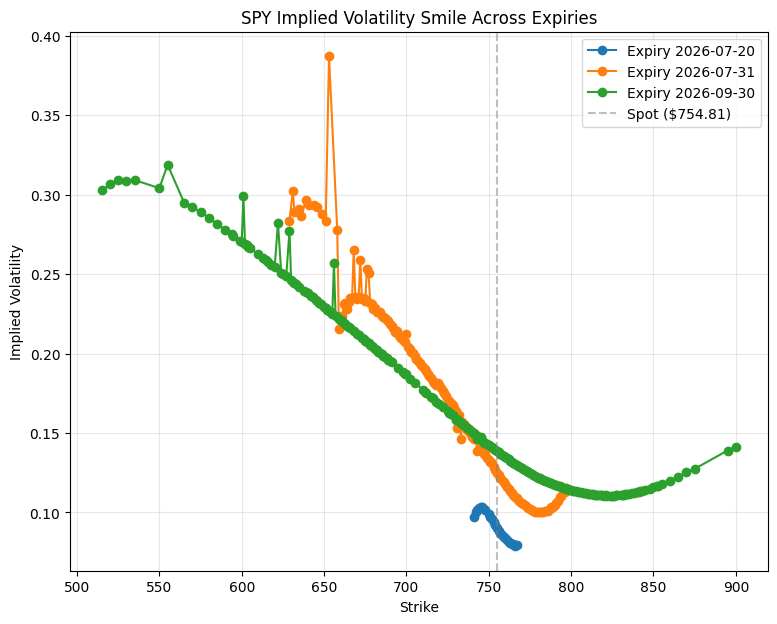

In [27]:
plt.figure(figsize=(9,7))
for exp in iv_df['expiry'].unique():
    sub = iv_df[iv_df['expiry'] == exp].sort_values('strike')
    plt.plot(sub['strike'], sub['implied_vol'], 'o-', label=f"Expiry {exp}")

plt.axvline(spot, color='gray', linestyle='--', alpha=0.5, label=f"Spot (${spot:.2f})")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.title("SPY Implied Volatility Smile Across Expiries")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Calibration Discussion

Implied volatilities were extracted from a snapshot of SPY call options across three expiries (2026-07-20, 2026-07-31, 2026-09-30), pulled at market close on 2026-07-15 21:47:04, with spot at $754.81 and a risk-free rate of 3.69%. Contracts were filtered on positive bid/ask, volume > 0, time to expiry greater than ~3.65 days, and relative bid-ask spread under 15%, leaving 496 contracts for calibration.

The implied vol solver (Newton-Raphson with Brent's method as fallback) converged for 401 of the 496 contracts (80.8%); 95 contracts (19.2%) failed to produce a convergent solution under either method. Failures were not randomly distributed — they concentrated in two regimes with a common underlying cause: deep in-the-money contracts (strikes 375–440, versus spot $754.81), where price is dominated by intrinsic value and vega approaches zero, and near-the-money contracts on the shortest-dated expiry (2026-07-20, five days to expiry at the time of the pull), where vega is small simply because time value is small. In both cases, a near-zero vega means option price carries almost no information about volatility, so implied vol is effectively unidentifiable from price alone. This is a genuine limitation of price-based calibration in these regimes, not a defect in the solver. The failure count by expiry (17 for 2026-07-20, 55 for 2026-07-31, 23 for 2026-09-30) reflects this: the 2026-07-31 expiry carries the bulk of the deep-ITM failures, while 2026-07-20's failures are concentrated near the money, consistent with the short-dated-vega explanation.

All three expiries show pronounced skew rather than a flat smile: implied volatility rises sharply as strike decreases below spot, consistent with the well-documented equity-index pattern of elevated pricing for downside protection. This directly contradicts Black-Scholes' constant-volatility assumption: if the model were correctly specified, implied vol would be flat across strikes for a fixed expiry. The non-flat curve is not a flaw in the calibration procedure; it is the calibration procedure correctly revealing that the market prices risk (tail risk, non-normal skewness in returns) that the lognormal-returns assumption underlying Black-Scholes does not capture. Skew was visibly steeper for the two shorter-dated expiries than for the longer-dated 2026-09-30 expiry, consistent with the standard term-structure pattern of more acute near-term tail-risk pricing that flattens somewhat as the horizon extends.

One data quality limitation is disclosed rather than filtered away: a single contract near strike 655 on the 2026-07-31 expiry produced an implied volatility (~0.39) sharply inconsistent with neighboring strikes, most likely due to a stale or unusually wide quote that survived the spread and volume filters. Tightening the filters further to exclude this point risked removing legitimate data elsewhere in the chain, so it was retained rather than suppressed. This, together with the vega-driven failure clusters above, is a reminder that real market data, unlike synthetic test cases, contains genuine noise and identification limits that a calibration pipeline must disclose rather than quietly discard.

# Test Suite

In [28]:
def run_test(name, test_fn):
    try:
        test_fn()
        print(f"PASS: {name}")
        return True
    except AssertionError as e:
        print(f"FAIL: {name} — {e}")
        return False
    except Exception as e:
        print(f"ERROR: {name} — {e}")
        return False

In [29]:
def test_bs_reference_values():

    price = BlackScholes().price(test_option)
    assert abs(price - 4.5817) < 1e-3, f"Expected ~4.5817, got {price}"

def test_bs_put_call_parity_property():
    test_put_call_parity_property()

def test_mc_seed_reproducibility():
    test_seed_reproducibility()

def test_mc_variance_reduction():
    mc = MonteCarlo(n_sims=100_000, seed=7)
    naive_se = mc.standard_error(test_option)
    _, anti_se = mc.price_antithetic(test_option)
    _, cv_se = mc.price_control_variate(test_option)
    assert anti_se < naive_se, "Antithetic did not reduce variance"
    assert cv_se < naive_se, "Control variate did not reduce variance"
    assert cv_se < anti_se, "Control variate should outperform antithetic for this payoff"

def test_binomial_convergence():
    bs_price = BlackScholes().price(test_option)
    tree_price = BinomialTree().price_european(test_option, n_steps=5000)
    assert abs(tree_price - bs_price) < 1e-3, f"Tree did not converge to BS: {tree_price} vs {bs_price}"

def test_american_put_premium():
    put = replace(test_option, option_type="put")
    euro = BinomialTree().price_european(put)
    amer = BinomialTree().price_american(put)
    assert amer >= euro - 1e-8, "American price should never be less than European"

def test_american_call_equals_european():
    euro_call = BinomialTree().price_european(test_option)
    amer_call = BinomialTree().price_american(test_option)
    assert np.isclose(euro_call, amer_call, atol=1e-4), "American call should equal European call without dividends"

In [30]:
tests = [
    ("BS reference values", test_bs_reference_values),
    ("BS put-call parity (property-based)", test_bs_put_call_parity_property),
    ("MC seed reproducibility", test_mc_seed_reproducibility),
    ("MC variance reduction ordering", test_mc_variance_reduction),
    ("Binomial convergence to BS", test_binomial_convergence),
    ("American put >= European put", test_american_put_premium),
    ("American call == European call (no dividends)", test_american_call_equals_european),
]

results = [run_test(name, fn) for name, fn in tests]

print("\n" + "="*50)
if all(results):
    print(f"ALL {len(tests)} TESTS PASSED")
else:
    print(f"{sum(results)}/{len(tests)} TESTS PASSED — see failures above")

PASS: BS reference values
PASS: BS put-call parity (property-based)
PASS: MC seed reproducibility
PASS: MC variance reduction ordering
PASS: Binomial convergence to BS
PASS: American put >= European put
PASS: American call == European call (no dividends)

ALL 7 TESTS PASSED


# API Demo

In [31]:
!pip install fastapi uvicorn pyngrok nest-asyncio -q

In [32]:
from fastapi import FastAPI
from pydantic import BaseModel
from typing import Literal

app = FastAPI(title="Options Pricing Engine API")

class OptionRequest(BaseModel):
    spot: float
    strike: float
    expiry: float
    rate: float
    volatility: float
    option_type: Literal["call", "put"]
    exercise_style: Literal["european", "american"] = "european"

class MethodResult(BaseModel):
    price: float
    greeks: dict | None = None
    metadata: dict

class PricingResponse(BaseModel):
    black_scholes: MethodResult | None = None
    monte_carlo: MethodResult
    binomial_tree: MethodResult

@app.post("/price", response_model=PricingResponse)
def price_option(req: OptionRequest):
    option = Option(
        spot=req.spot, strike=req.strike, expiry=req.expiry,
        rate=req.rate, volatility=req.volatility,
        option_type=req.option_type, exercise_style=req.exercise_style
    )

    response = {}

    # Black-Scholes only valid for European
    if req.exercise_style == "european":
        bs = BlackScholes()
        response["black_scholes"] = MethodResult(
            price=bs.price(option),
            greeks=bs.greeks(option),
            metadata=bs.metadata()
        )

    mc = MonteCarlo(n_sims=100_000, seed=42)
    response["monte_carlo"] = MethodResult(
        price=mc.price(option),
        greeks=None,  # documented limitation from Phase 2 — MC greeks not implemented
        metadata=mc.metadata()
    )

    bt = BinomialTree(n_steps=500)
    response["binomial_tree"] = MethodResult(
        price=bt.price(option),
        greeks=None,  # tree doesn't compute Greeks in this implementation either
        metadata=bt.metadata()
    )

    return response

@app.get("/health")
def health_check():
    return {"status": "ok"}

In [36]:
import nest_asyncio
import uvicorn
from pyngrok import ngrok
import threading
from google.colab import userdata
ngrokid=userdata.get('NGROK')

nest_asyncio.apply()

def run_server():
    uvicorn.run(app, host="0.0.0.0", port=8000, log_level="warning")

thread = threading.Thread(target=run_server, daemon=True)
thread.start()

import time
time.sleep(2)

ngrok.set_auth_token(ngrokid)
public_url = ngrok.connect(8000)
tunnel_url = public_url.public_url
print(f"Public URL: {tunnel_url}")

ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use


Public URL: https://946c-35-226-51-71.ngrok-free.app


In [34]:
#!kill -9 $(lsof -t -i:8000) 2>/dev/null

In [37]:
import requests

payload = {
    "spot": 100.0,
    "strike": 105.0,
    "expiry": 0.5,
    "rate": 0.05,
    "volatility": 0.20,
    "option_type": "call",
    "exercise_style": "european"
}

resp = requests.post(f"{tunnel_url}/price", json=payload)
print(resp.status_code)
print(resp.json())

200
{'black_scholes': {'price': 4.581680167540007, 'greeks': {'delta': 0.46116022571905085, 'gamma': 0.028075683527420743, 'theta': -0.030523229467073025, 'rho': 0.20767171202182538, 'vega': 0.2807568352742074}, 'metadata': {'method': 'Black Scholes', 'time_complexity': 'O(1)'}}, 'monte_carlo': {'price': 4.576595466241099, 'greeks': None, 'metadata': {'method': 'monte_carlo', 'complexity': 'O(N)'}}, 'binomial_tree': {'price': 4.581313687037349, 'greeks': None, 'metadata': {'method': 'binomial_tree', 'complexity': 'O(n^2)'}}}


**Note:** The public URL above was generated during an interactive Colab session and is not permanent — it expires when the session ends. The API application code itself is fully functional and can be run in any environment with the dependencies installed; this cell demonstrates a live request/response cycle at the time the notebook was executed, saved as output for reference.

In [38]:
#ngrok.disconnect(tunnel_url)
#ngrok.kill()

## Discussion & Synthesis

This project implemented and compared three option pricing methods: closed-form Black-Scholes, Monte Carlo simulation with variance reduction, and a binomial tree with Richardson extrapolation. It then validated against known reference values and internal consistency checks (put-call parity, American premium bounds), then calibrated against a real SPY options snapshot.

**Method comparison.** Across the tested parameter range, the binomial tree dominated both Monte Carlo variants on accuracy per unit of runtime for this single-underlying European/American case, consistent with the theoretical expectation that Monte Carlo's O(1/√N) convergence is fundamentally slower than the tree's O(1/n) convergence for low-dimensional problems. Control variate Monte Carlo, once corrected for a units-mismatch bug in the beta estimation (the control variate was initially computed in undiscounted terms against a discounted payoff), outperformed antithetic variates as theory predicts, though both remained slower than the tree at every tested runtime. This does not argue against Monte Carlo's practical relevance; its value proposition is dimension-independence for path-dependent and multi-asset payoffs where trees become intractable, not raw speed on a problem trees already solve efficiently.

**American exercise.** The binomial tree correctly recovered near-zero early-exercise premium for calls (matching the theoretical no-early-exercise result absent dividends) and a positive, moneyness- and expiry-dependent premium for puts, consistent with the economic intuition that early exercise has value only when there is a reason to lock in proceeds sooner. Deep in-the-money puts with longer time horizons showed the largest premium.

**Calibration.** Implied volatility extraction from a real SPY options snapshot (pulled 2026-07-15 21:47:04, spot $754.81, r = 3.69%) across three expiries produced 401 converged implied vols from 496 filtered contracts, an 80.8% solve rate. The 19.2% failure rate was not random: it concentrated in deep in-the-money contracts and in near-the-money contracts on the shortest-dated expiry, both regimes where vega approaches zero and implied vol becomes effectively unidentifiable from price alone. This is a genuine limitation of the method. Converged results showed pronounced skew across all three expiries, directly demonstrating that Black-Scholes' constant-volatility assumption is misspecified relative to market prices, with skew steeper at shorter maturities which is consistent with near-term tail-risk pricing. One anomalous data point (2026-07-31 expiry, strike ~655) was retained and disclosed rather than filtered out, since tightening filters further risked removing legitimate data elsewhere in the chain.

**Limitations.** This project used a single point-in-time market snapshot rather than a live or historical panel, so calibration results reflect one moment's market state rather than a robust average across time. Monte Carlo Greeks were not implemented, since they require pathwise or likelihood-ratio methods beyond this project's scope. American-exercise Monte Carlo (Longstaff-Schwartz) was discussed but not implemented, as it is a materially different algorithm from the rest of the codebase and would have doubled scope for limited additional insight. The API layer demonstrates a working service interface but was not deployed persistently. The demo reflects a live request/response cycle at the time the notebook was executed, not an ongoing service.